In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import os
import cv2
from sklearn.utils import class_weight
import numpy as np


2026-03-28 13:14:08.164417: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 13:14:08.583540: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-28 13:14:10.682508: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/vman/tf-gpu/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWar

In [3]:
yes_count = len(os.listdir("dataset/yes"))
no_count = len(os.listdir("dataset/no"))
print("Yes:", yes_count)
print("No:", no_count)

Yes: 155
No: 98


In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)
val_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 253 files belonging to 2 classes.
Using 203 files for training.


I0000 00:00:1774703652.223094     861 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [5]:
class_names = train_data.class_names
print(class_names)

['no', 'yes']


2026-03-28 13:14:13.525358: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


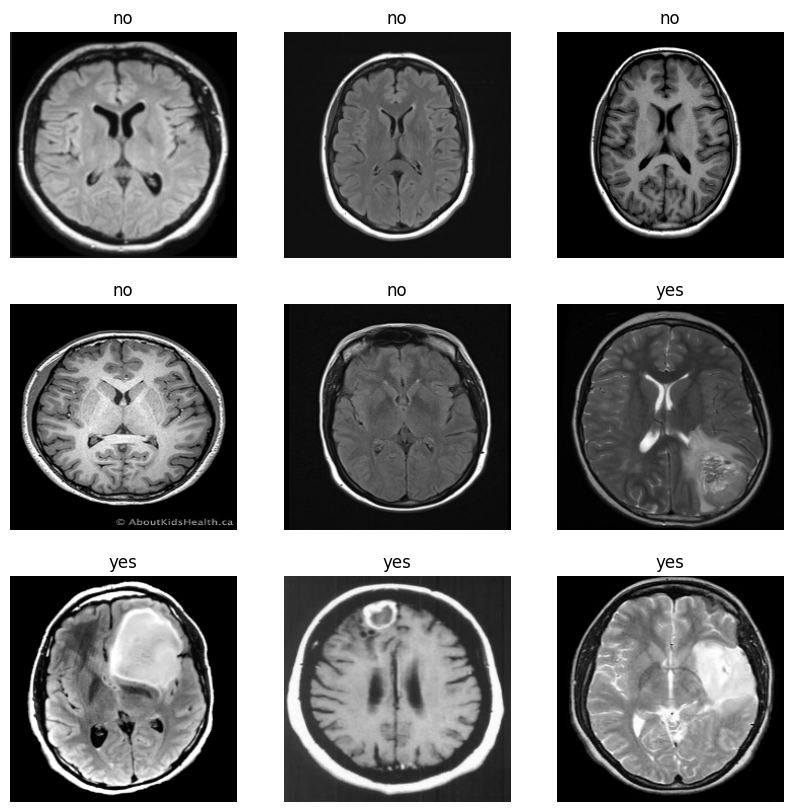

In [6]:
for images, labels in train_data.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
yes_count = 155
no_count = 98
total = yes_count + no_count
num_classes = 2
class_weights = {
    0: total / (num_classes * no_count),
    1: total / (num_classes * yes_count)
}
print(class_weights)

{0: 1.2908163265306123, 1: 0.8161290322580645}


In [8]:
base = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base.trainable = False 
model = tf.keras.Sequential([
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10


2026-03-28 13:14:18.623370: I external/local_xla/xla/service/service.cc:163] XLA service 0x7322580030b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-28 13:14:18.623460: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-28 13:14:18.761934: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-28 13:14:19.788377: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-03-28 13:14:19.935882: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 13:14:20.

2/7 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5312 - loss: 1.1953 - precision: 0.8286 - recall: 0.3738 

I0000 00:00:1774703665.671780    3067 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5271 - loss: 1.2249 - precision: 0.6413 - recall: 0.4836 - val_accuracy: 0.5800 - val_loss: 0.8282 - val_precision: 0.9286 - val_recall: 0.3939
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7488 - loss: 0.5597 - precision: 0.7710 - recall: 0.8279 - val_accuracy: 0.8600 - val_loss: 0.4062 - val_precision: 0.8421 - val_recall: 0.9697
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.7635 - loss: 0.4454 - precision: 0.9205 - recall: 0.6639 - val_accuracy: 0.9000 - val_loss: 0.3877 - val_precision: 0.9667 - val_recall: 0.8788
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.8571 - loss: 0.3151 - precision: 0.9115 - recall: 0.8443 - val_accuracy: 0.8600 - val_loss: 0.3712 - val_precision: 0.8421 - val_recall: 0.9697
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8916 - loss: 0.3248 - precision: 0.8846 - recall: 0.9426 - val_accuracy: 0.8800 - val_loss: 0.3340 - val_precision: 0.9

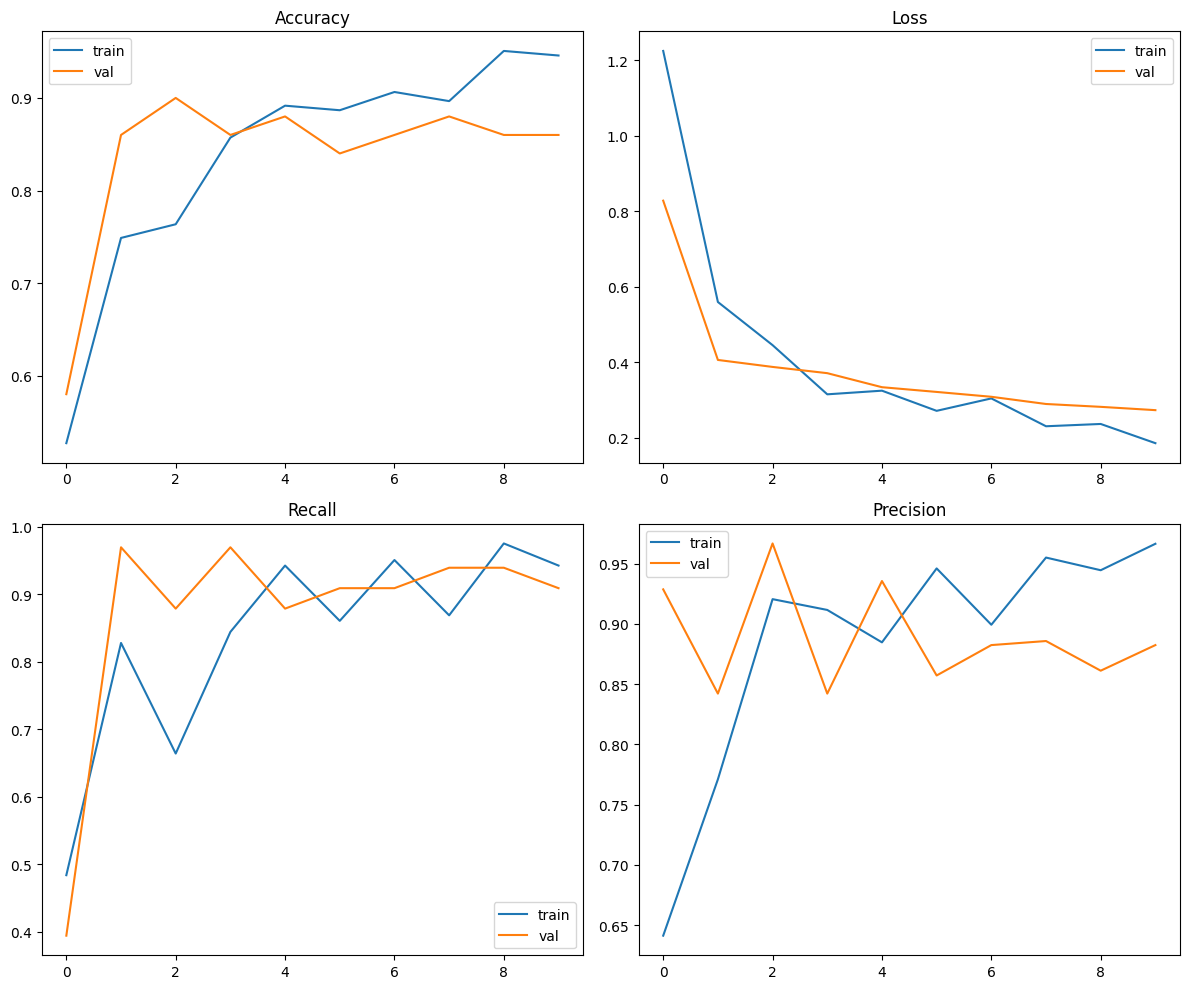

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(2,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.subplot(2,2,3)
plt.plot(history.history['recall'], label='train')
plt.plot(history.history['val_recall'], label='val')
plt.title("Recall")
plt.legend()

plt.subplot(2,2,4)
plt.plot(history.history['precision'], label='train')
plt.plot(history.history['val_precision'], label='val')
plt.title("Precision")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
inputs = tf.keras.Input(shape=(224,224,3))
x = inputs
for layer in model.layers:
    x = layer(x)
functional_model = tf.keras.Model(inputs, x)

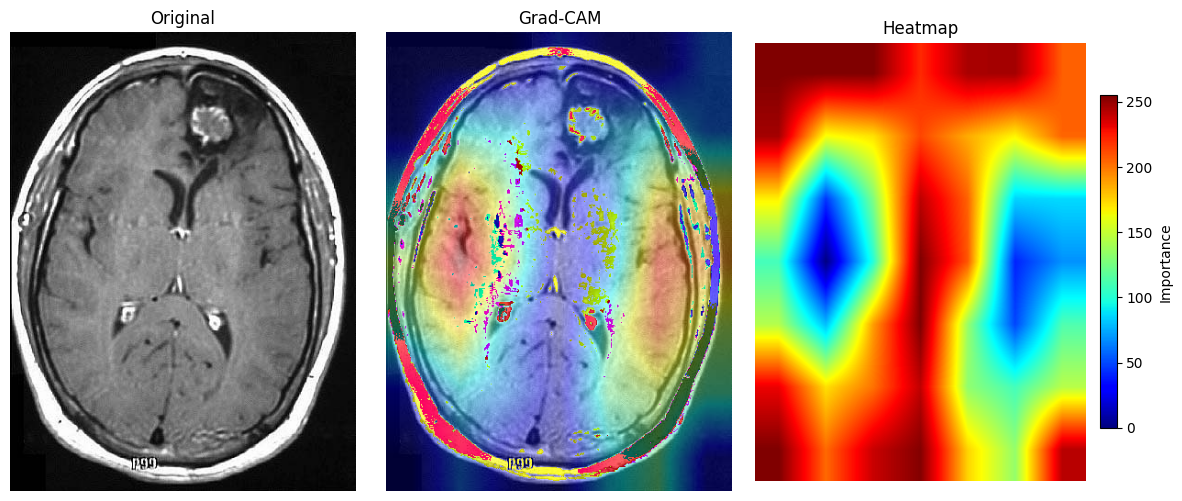

In [ ]:
img_path = "dataset/yes/Y12.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

base = model.layers[0]

with tf.GradientTape() as tape:
    x = img_tensor
    
    for layer in model.layers:
        x = layer(x)
        if layer == base:
            conv_outputs = x
    
    predictions = x
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap)

img = cv2.imread(img_path)
heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis("off")

ax = plt.subplot(1,3,3)
im = ax.imshow(heatmap, cmap='jet')
ax.set_title("Heatmap")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Importance")

plt.tight_layout()
plt.show()